Linear Regression

In [20]:
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

data = fetch_california_housing()

X = data.data[:, 0].reshape(-1, 1)
y = data.target



In [30]:
import pandas as pd

df = pd.DataFrame(housing.data, columns=housing.feature_names)
df["Price"] = housing.target

df

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422
...,...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09,0.781
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21,0.771
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22,0.923
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32,0.847


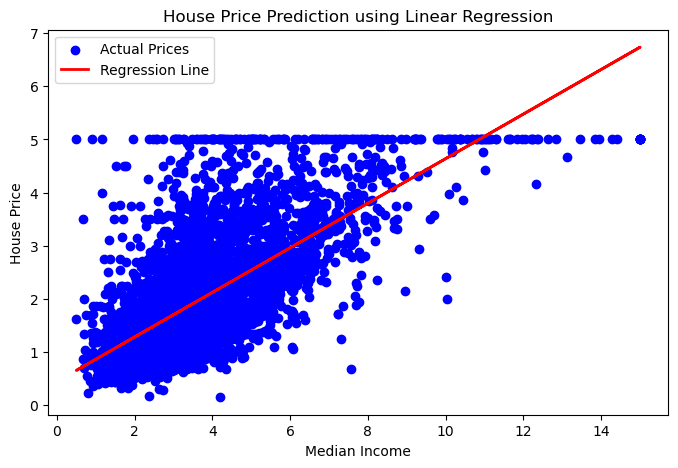

In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

plt.figure(figsize=(8,5))
plt.scatter(X_test, y_test, color='blue', label='Actual Prices')
plt.plot(X_test, y_pred, color='red', linewidth=2, label='Regression Line')

plt.title("House Price Prediction using Linear Regression")
plt.xlabel("Median Income")
plt.ylabel("House Price")
plt.legend()
plt.show()

In [4]:
print("Slope (Coefficient):", model.coef_[0])
print("Intercept:", model.intercept_)

Slope (Coefficient): 0.4193384939381273
Intercept: 0.4445972916907872


In [5]:
sample = [[16.0]]   

predicted_price = model.predict(sample)

print("Median Income:", sample[0][0])
print("Predicted House Price:", predicted_price[0])

Median Income: 16.0
Predicted House Price: 7.154013194700823


Multiple Regression

R2 Score: 0.5757877060324512
Predicted House Price: 4.138181212997225


c:\ProgramData\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


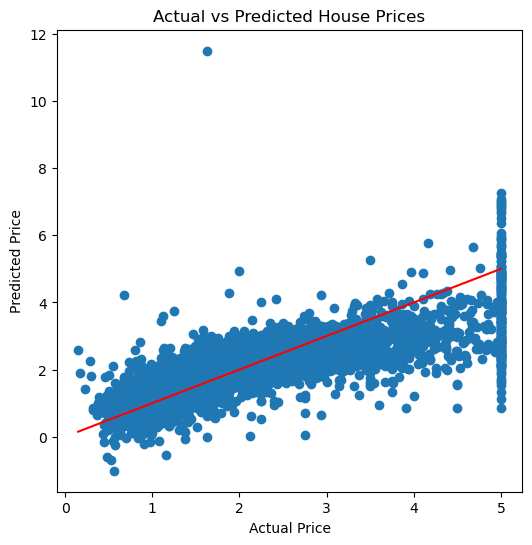

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

housing = fetch_california_housing()

X = pd.DataFrame(housing.data, columns=housing.feature_names)
y = housing.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)



print("R2 Score:", r2_score(y_test, y_pred))

sample = [[8.3, 41, 6.98, 1.02, 322, 2.55, 37.88, -122.23]]
prediction = model.predict(sample)
print("Predicted House Price:", prediction[0])

plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred)
plt.plot([min(y_test), max(y_test)],
         [min(y_test), max(y_test)],
         color="red")
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted House Prices")
plt.show()

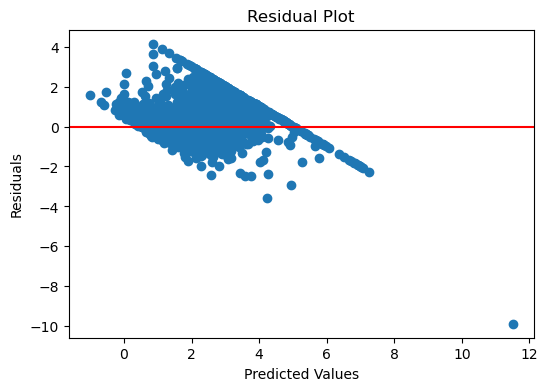

In [10]:
residuals = y_test - y_pred

plt.figure(figsize=(6,4))
plt.scatter(y_pred, residuals)
plt.axhline(y=0, color='red')
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

Polynomial Regression 

R2 Score: 0.46331772769346224
Intercept: 0.19756732564563095
Coefficients: [ 0.          0.53359111 -0.010508  ]
Predicted House Price: 2.602822888308787


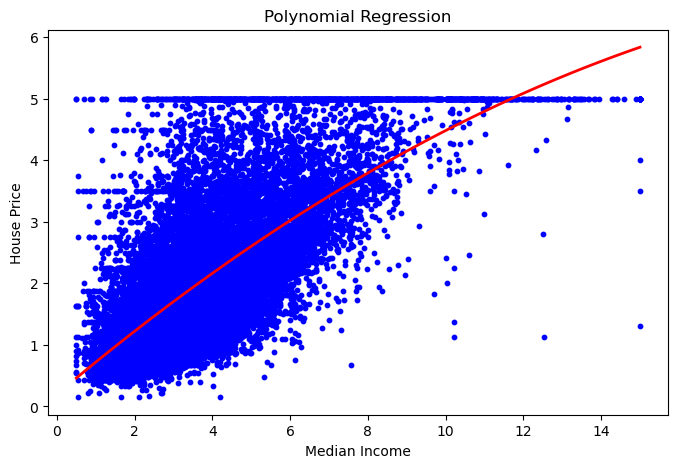

In [31]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

housing = fetch_california_housing()

X = housing.data[:, 0].reshape(-1, 1)
y = housing.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

poly = PolynomialFeatures(degree=2)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

model = LinearRegression()
model.fit(X_train_poly, y_train)

y_pred = model.predict(X_test_poly)

print("R2 Score:", r2_score(y_test, y_pred))
print("Intercept:", model.intercept_)
print("Coefficients:", model.coef_)

sample = [[5.0]]
sample_poly = poly.transform(sample)
prediction = model.predict(sample_poly)
print("Predicted House Price:", prediction[0])

X_plot = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)
X_plot_poly = poly.transform(X_plot)
y_plot = model.predict(X_plot_poly)

plt.figure(figsize=(8,5))
plt.scatter(X, y, color="blue", s=10)
plt.plot(X_plot, y_plot, color="red", linewidth=2)
plt.xlabel("Median Income")
plt.ylabel("House Price")
plt.title("Polynomial Regression")
plt.show()

Lasso Regression

In [13]:
from sklearn.linear_model import Ridge

model = Ridge(alpha=1.0)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Intercept:", model.intercept_)
print("Coefficient:", model.coef_[0])

Intercept: 0.44462447061609756
Coefficient: 0.41933149042192736


In [ ]:
from sklearn.linear_model import Lasso

model = Ridge(alpha=1.0)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Intercept:", model.intercept_)
print("Coefficient:", model.coef_[0])